建库阶段，create_cistarget_motif_databases.py的-f参数应该选择蜜蜂的什么区域？现有的结论大多是彼此矛盾的:
- Mu et al., 2025: 基因起点（而非某个转录本的TSS）的上游5kb和下游2kb
- aertslab的官方issue，即: https://github.com/aertslab/create_cisTarget_databases/issues/4 。指出：“for drosophila, the default in i-cisTarget is 5kb upstream plus the full transcript, for human and mouse 10kb up- and 10kb downstream of the TSS.” 但是，“full transcript”指的是果蝇单个基因的哪个转录本仍不确定
- 表达最高的isoform对应的TSS，上游5kb，下游5kb
- 2015年的i-cisTarget文章（i-cisTarget 2015 update: generalized cis-regulatory enrichment analysis in human, mouse and fly）指出，“For human and mouse the default space is 20 kb around TSS and for fly it is set to 5 kb upstream of TSS and all introns.” 看起来与（2）中的做法近似，但注意，此处细节不一样，果蝇使用的是all introns而非 full transcript。以及，仍不确定使用的是果蝇哪个转录本的TSS

后续经过讨论，得知TSS和基因起始位点可能实际上相差并不大，甚至单个基因最前方的转录本TSS可能就是基因起始位点，因此将在蜜蜂中进行验证：

In [2]:
%%bash

mkdir -p "./metadata"
awk '$0 !~ /^#/ && ($3=="gene" || $3=="transcript")' "../../01_create_cistarget_db/gtf/Apis_mellifera.gtf" > "./metadata/Amel_genes_transcript.gtf"

In [3]:
import pyranges as pr 

Amel_g_t = pr.read_gtf("./metadata/Amel_genes_transcript.gtf").df
Amel_g_t

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_source,gene_biotype,transcript_id,transcript_source,transcript_biotype,tag,gene_name,transcript_name
0,CM009931.2,RefSeq,gene,2597188,2601290,.,+,.,LOC100576147,RefSeq,protein_coding,NaN,NaN,NaN,NaN,NaN,NaN
1,CM009931.2,RefSeq,transcript,2597188,2601290,.,+,.,LOC100576147,RefSeq,protein_coding,XM_006559882,RefSeq,protein_coding,Ensembl_canonical,NaN,NaN
2,CM009931.2,RefSeq,gene,4532529,4535187,.,+,.,LOC100577342,RefSeq,protein_coding,NaN,NaN,NaN,NaN,NaN,NaN
3,CM009931.2,RefSeq,transcript,4532529,4535187,.,+,.,LOC100577342,RefSeq,protein_coding,XM_006561922,RefSeq,protein_coding,Ensembl_canonical,NaN,NaN
4,CM009931.2,RefSeq,gene,5362635,5365418,.,+,.,LOC727596,RefSeq,protein_coding,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40803,QIUM02000211.1,RefSeq,transcript,0,3962,.,+,.,LOC113219387,RefSeq,rRNA,XR_003306469,RefSeq,rRNA,Ensembl_canonical,NaN,NaN
40804,QIUM02000217.1,RefSeq,gene,556,1523,.,-,.,LOC113219358,RefSeq,protein_coding,NaN,NaN,NaN,NaN,NaN,NaN
40805,QIUM02000217.1,RefSeq,transcript,556,1523,.,-,.,LOC113219358,RefSeq,protein_coding,XM_026445952,RefSeq,protein_coding,Ensembl_canonical,NaN,NaN
40806,QIUM02000219.1,RefSeq,gene,2141,4064,.,+,.,LOC113219341,RefSeq,rRNA,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
Amel_g_t_subset = Amel_g_t[["Feature", "Start", "gene_id"]]
Amel_g_t_subset 

,Feature,Start,gene_id
0,gene,2597188,LOC100576147
1,transcript,2597188,LOC100576147
2,gene,4532529,LOC100577342
3,transcript,4532529,LOC100577342
4,gene,5362635,LOC727596
...,...,...,...
40803,transcript,0,LOC113219387
40804,gene,556,LOC113219358
40805,transcript,556,LOC113219358
40806,gene,2141,LOC113219341


In [15]:
gene_start = Amel_g_t_subset[Amel_g_t_subset["Feature"] == "gene"].set_index("gene_id")["Start"]
trans = Amel_g_t_subset[Amel_g_t_subset["Feature"] == "transcript"]
mismatch = (trans["Start"] != trans["gene_id"].map(gene_start)).groupby(trans["gene_id"]).sum()

In [23]:
mismatch.value_counts()

0     8994
1     1732
2      668
3      347
4      214
5      129
6       79
8       48
7       45
9       37
10      20
12      14
13      11
11      11
14       9
15       8
16       4
17       3
19       3
49       2
27       2
33       2
26       2
23       2
22       2
18       2
25       2
32       1
35       1
21       1
24       1
30       1
20       1
dtype: int64

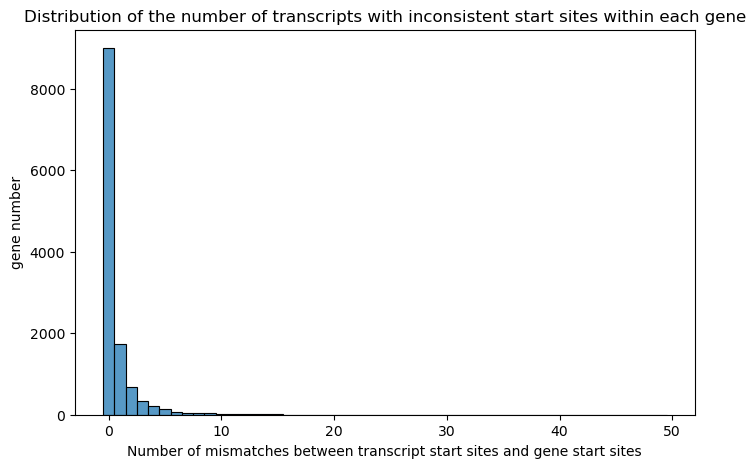

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(mismatch, bins=range(mismatch.max() + 2), discrete=True)
plt.xlabel("Number of mismatches between transcript start sites and gene start sites")
plt.ylabel("gene number")
plt.title("Distribution of the number of transcripts with inconsistent start sites within each gene")
plt.show()